# Nth Item Recall

> Show when in the recall sequence a particular studied item tends to appear.

The nth-item recall curve shows when in the recall sequence a particular studied item tends to be recalled. Two variants are provided: a *simple* curve that computes unconditional recall probability at each output position, and a *conditional* curve that conditions on the item being available (not yet recalled) and the recall sequence continuing (the previous output was a valid recall, not a termination).

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.nth_item_recall import plot_conditional_nth_item_recall_curve, plot_simple_nth_item_recall_curve
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
query_study_position = 0
mode = "conditional"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

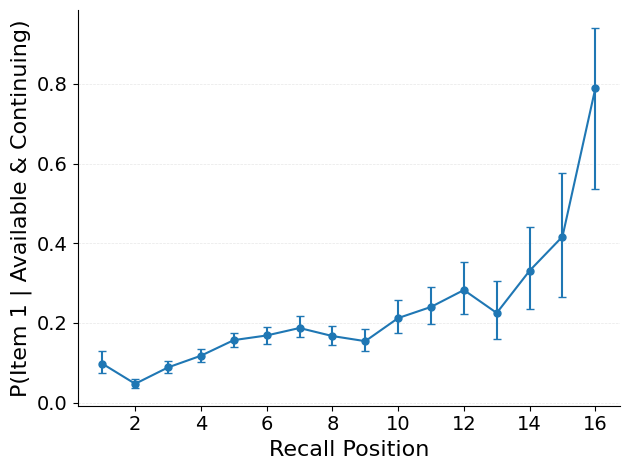

In [4]:
if mode == "conditional":
    plot_conditional_nth_item_recall_curve(data, trial_mask, query_study_position=query_study_position, confidence_level=confidence_level)
else:
    plot_simple_nth_item_recall_curve(data, trial_mask, query_study_position=query_study_position, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows output position and the y-axis shows the probability of recalling the queried study position at that point in the sequence. Key patterns:

- **Early peak for recency items**: items near the end of the study list tend to be recalled early in the output sequence.
- **Late peak for primacy items**: items near the start tend to appear later in the output sequence.
- **Conditional vs. simple**: the conditional curve removes the declining baseline of available items, isolating the retrieval dynamics.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `query_study_position` — 0-based study position to track across the recall sequence.
- `mode` — `"conditional"` or `"simple"`. Conditional divides by availability; simple reports raw probability.
- `confidence_level` — confidence level for subject-wise error bars.
